# Homework 4: Midway Check-in Final Project

In [1]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

## Problem 1: Setup

### 1.1 Dataset selection

Picked from existing Google sheets list: Countries Life Expectancy (Kaggle)<br>
Problem to solve: Does immunization against certain diseases impact a country's life expectancy?

### 1.2 Github setup

Accepted and cloned

## Problem 2: Data Collection

### 2.1 Dataset description

The dataset I chose was Countries Life Expectancy, found on Kaggle. This dataset takes information like population, major diseases, infant deaths, alcohol and more to uncover reasons why countries have different life expectancies. The purpose of the dataset is to understand the link between healthcare, socioeconomic factors, and life expectancy in different countries. The country’s development status and population are taken into account when looking at factors that can affect the life expectancy of a country. The percentages of people who are immunized against diseases like Hepatitis B, Polio and Measles are also reported. The number of deaths by HIV/AIDS, infant deaths and under 5-years deaths are also taken into consideration. Things like GDP, BMI and Liters of alcohol consumed are also looked at. These things might impact the overall health and wellbeing of a country’s population and could pose a factor in a country’s life expectancy age. The number of years that people go to school in each country is also looked at and the ratio of government medical-health expenses to total government expenses is given as a percentage. The data is collected and shown from the year 2001 to 2015 for each country, so we can see if the life expectancy goes up or down in that time frame. 

### 2.2 Dataset download

In [2]:
life_expectancy_df = pd.read_csv('life_expectancy.csv')
life_expectancy_df.head(20)

,Country,Year,Status,Population,Hepatitis B,Measles,Polio,Diphtheria,HIV/AIDS,infant deaths,under-five deaths,Total expenditure,GDP,BMI,thinness 1-19 years,Alcohol,Schooling,Life expectancy
0,Afghanistan,2015,Developing,33736494.0,65.0,1154,6.0,65.0,0.1,62,83,8.16,584.259210,19.1,17.2,0.01,10.1,65.0
1,Afghanistan,2014,Developing,327582.0,62.0,492,58.0,62.0,0.1,64,86,8.18,612.696514,18.6,17.5,0.01,10.0,59.9
2,Afghanistan,2013,Developing,31731688.0,64.0,430,62.0,64.0,0.1,66,89,8.13,631.744976,18.1,17.7,0.01,9.9,59.9
3,Afghanistan,2012,Developing,3696958.0,67.0,2787,67.0,67.0,0.1,69,93,8.52,669.959000,17.6,17.9,0.01,9.8,59.5
4,Afghanistan,2011,Developing,2978599.0,68.0,3013,68.0,68.0,0.1,71,97,7.87,63.537231,17.2,18.2,0.01,9.5,59.2
5,Afghanistan,2010,Developing,2883167.0,66.0,1989,66.0,66.0,0.1,74,102,9.20,553.328940,16.7,18.4,0.01,9.2,58.8
6,Afghanistan,2009,Developing,284331.0,63.0,2861,63.0,63.0,0.1,77,106,9.42,445.893298,16.2,18.6,0.01,8.9,58.6
7,Afghanistan,2008,Developing,2729431.0,64.0,1599,64.0,64.0,0.1,80,110,8.33,373.361116,15.7,18.8,0.03,8.7,58.1
8,Afghanistan,2007,Developing,26616792.0,63.0,1141,63.0,63.0,0.1,82,113,6.73,369.835796,15.2,19.0,0.02,8.4,57.5
9,Afghanistan,2006,Developing,2589345.0,64.0,1990,58.0,58.0,0.1,84,116,7.43,272.563770,14.7,19.2,0.03,8.1,57.3


In [3]:
diseases_df = life_expectancy_df.drop(columns=['Status', 'Measles', 'under-five deaths', 'Population', 'HIV/AIDS', 'infant deaths', 'Alcohol', 'Schooling', 'GDP', 'BMI', 'Total expenditure', 'thinness  1-19 years'])

In [4]:
diseases_df

,Country,Year,Hepatitis B,Polio,Diphtheria,Life expectancy
0,Afghanistan,2015,65.0,6.0,65.0,65.0
1,Afghanistan,2014,62.0,58.0,62.0,59.9
2,Afghanistan,2013,64.0,62.0,64.0,59.9
3,Afghanistan,2012,67.0,67.0,67.0,59.5
4,Afghanistan,2011,68.0,68.0,68.0,59.2
...,...,...,...,...,...,...
2843,Zimbabwe,2004,68.0,67.0,65.0,44.3
2844,Zimbabwe,2003,7.0,7.0,68.0,44.5
2845,Zimbabwe,2002,73.0,73.0,71.0,44.8
2846,Zimbabwe,2001,76.0,76.0,75.0,45.3


## Problem 3: Data Preprocessing

### 3.1 Data cleaning

**Since the problem that I hope to solve is how immunization against certain diseases can affect a country's life expectancy, I decided to drop some of the columns that I will not be using to answer my question**

**The dieseases_df shows the percentage of people who were immunized against Hepatitis B, Polio and Diphtheria. The data shows the Life expectancy and immunization percentages from 2000-2015 for each country**

In [5]:
# (1) Data exploration

In [6]:
diseases_df.info()

# info looks good. The immunization percentages are floats; country names and status are objects

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          2848 non-null   object 
 1   Year             2848 non-null   int64  
 2   Hepatitis B      2306 non-null   float64
 3   Polio            2829 non-null   float64
 4   Diphtheria       2829 non-null   float64
 5   Life expectancy  2848 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 133.6+ KB


In [7]:
# All the differnt countries
diseases_df['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', "Côte d'Ivoire", 'Cabo Verde', 'Cambodia',
       'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile',
       'Colombia', 'Comoros', 'Congo', 'Costa Rica', 'Croatia', 'Cuba',
       'Cyprus', 'Czechia', "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador',
       'Equatorial Guinea', 'Eritrea', 'Estonia', 'Fiji', 'Finland',
       'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana',
       'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Biss

In [8]:
diseases_df.sample(50)

,Country,Year,Hepatitis B,Polio,Diphtheria,Life expectancy
1641,Micronesia (Federated States of),2006,84.0,81.0,67.0,68.0
174,Bahamas,2001,21.0,98.0,99.0,72.9
155,Azerbaijan,2004,5.0,78.0,77.0,68.4
1795,Nicaragua,2012,98.0,99.0,98.0,73.9
1177,Iran (Islamic Republic of),2006,98.0,99.0,98.0,72.2
264,Belize,2007,96.0,97.0,96.0,69.6
867,Finland,2012,NaN,99.0,99.0,84.0
1221,Israel,2010,97.0,95.0,95.0,81.7
2316,South Africa,2003,71.0,7.0,69.0,54.0
1254,Jamaica,2009,9.0,9.0,9.0,74.7


In [9]:
# Rounding each column to two decimal places

diseases_df['Hepatitis B'] = diseases_df['Hepatitis B'].round(2)

In [10]:
diseases_df['Polio'] = diseases_df['Polio'].round(2)

In [11]:
diseases_df['Diphtheria'] = diseases_df['Diphtheria'].round(2)

In [12]:
diseases_df.sample(10)

,Country,Year,Hepatitis B,Polio,Diphtheria,Life expectancy
1887,Pakistan,2000,NaN,65.0,62.0,62.8
1934,Peru,2001,NaN,9.0,9.0,72.4
557,Colombia,2002,78.0,83.0,81.0,71.8
2427,Sweden,2004,NaN,99.0,99.0,83.0
2123,Samoa,2004,54.0,26.0,55.0,71.4
43,Algeria,2004,81.0,86.0,86.0,72.3
1198,Iraq,2001,66.0,8.0,78.0,72.0
393,Bulgaria,2006,96.0,96.0,95.0,72.2
1633,Micronesia (Federated States of),2014,81.0,76.0,77.0,69.4
2550,Tonga,2009,84.0,86.0,84.0,72.5


In [13]:
# (2) Looking for missing values

In [14]:
# Looking at all the columns
diseases_df.columns

Index(['Country', 'Year', 'Hepatitis B', 'Polio', 'Diphtheria',
       'Life expectancy'],
      dtype='object')

In [15]:
print('Null in Country name:', life_expectancy_df['Country'].isnull().values.any())

Null in Country name: False


In [16]:
print('Null in year:', life_expectancy_df['Year'].isnull().values.any())

Null in year: False


In [17]:
print('Null in Hepatitis B:', life_expectancy_df['Hepatitis B'].isnull().values.any())
print('Number of Nan:',life_expectancy_df['Hepatitis B'].isna().sum())

Null in Hepatitis B: True
Number of Nan: 542


In [18]:
print('Null in Polio:', life_expectancy_df['Polio'].isnull().values.any())
print('Number of Nan:',life_expectancy_df['Polio'].isna().sum())

Null in Polio: True
Number of Nan: 19


In [19]:
print('Null in Diphtheria:', life_expectancy_df['Diphtheria'].isnull().values.any())
print('Number of Nan:',life_expectancy_df['Diphtheria'].isna().sum())

Null in Diphtheria: True
Number of Nan: 19


In [20]:
print('Null in Life expectancy:', life_expectancy_df['Life expectancy'].isnull().values.any())

Null in Life expectancy: False


Columns with null values: Population, Hepatitis B, Polio and Diphtheria<br>
Columns without null values: Name, Year, and Life expectancy

In [21]:
# (3) Handeling missing values

# Diseases: Hepatitis B, Polio and Diphtheria. Will replace NaN values with the average of each column

In [22]:
diseases_df['Hepatitis B'].fillna(round(diseases_df['Hepatitis B'].mean(skipna=True), 2), inplace=True)

In [23]:
diseases_df['Polio'].fillna(round(diseases_df['Polio'].mean(skipna=True), 2), inplace=True)

In [24]:
diseases_df['Diphtheria'].fillna(round(diseases_df['Diphtheria'].mean(skipna=True), 2), inplace=True)

In [25]:
print('Null in Hepatitis B:', diseases_df['Hepatitis B'].isnull().values.any())
print('Null in Polio:', diseases_df['Polio'].isnull().values.any())
print('Null in Diphtheria:', diseases_df['Diphtheria'].isnull().values.any())

Null in Hepatitis B: False
Null in Polio: False
Null in Diphtheria: False


In [26]:
diseases_2015_df = diseases_df[diseases_df['Year'] == 2015]

In [27]:
diseases_2015_df

,Country,Year,Hepatitis B,Polio,Diphtheria,Life expectancy
0,Afghanistan,2015,65.0,6.0,65.0,65.0
16,Albania,2015,99.0,99.0,99.0,77.8
32,Algeria,2015,95.0,95.0,95.0,75.6
48,Angola,2015,64.0,7.0,64.0,52.4
64,Antigua and Barbuda,2015,99.0,86.0,99.0,76.4
...,...,...,...,...,...,...
2768,Venezuela (Bolivarian Republic of),2015,87.0,87.0,87.0,74.1
2784,Viet Nam,2015,97.0,97.0,97.0,76.0
2800,Yemen,2015,69.0,63.0,69.0,65.7
2816,Zambia,2015,9.0,9.0,9.0,61.8


In [28]:
diseases_2000_df = diseases_df[diseases_df['Year'] == 2000]

In [29]:
diseases_2000_df

,Country,Year,Hepatitis B,Polio,Diphtheria,Life expectancy
15,Afghanistan,2000,62.00,24.0,24.0,54.8
31,Albania,2000,96.00,97.0,97.0,72.6
47,Algeria,2000,81.08,86.0,86.0,71.3
63,Angola,2000,81.08,3.0,28.0,45.3
79,Antigua and Barbuda,2000,81.08,96.0,95.0,73.6
...,...,...,...,...,...,...
2783,Venezuela (Bolivarian Republic of),2000,5.00,86.0,77.0,72.5
2799,Viet Nam,2000,81.08,96.0,96.0,73.4
2815,Yemen,2000,14.00,74.0,74.0,68.0
2831,Zambia,2000,81.08,85.0,85.0,43.8


In [30]:
# (4) Explain choosen method of dealing with missing data

**I chose to replace the NaN values with the average values of each column because I didn't think it would have been appropriate to just drop the rows with NaN values since the majority of the NaN values seemed to be in one column and I could still use the data in the other columns.**

**Also created diseases_2015_df and diseases_2000_df because the original dataset contained years and I wanted to see how the immunization percentages of 2000 and 2015 compared and how that impacts the life expectancy for 2015 and 2000 as well**

### 3.2 Outlier detection

In [31]:
# (1) Checking for outliers

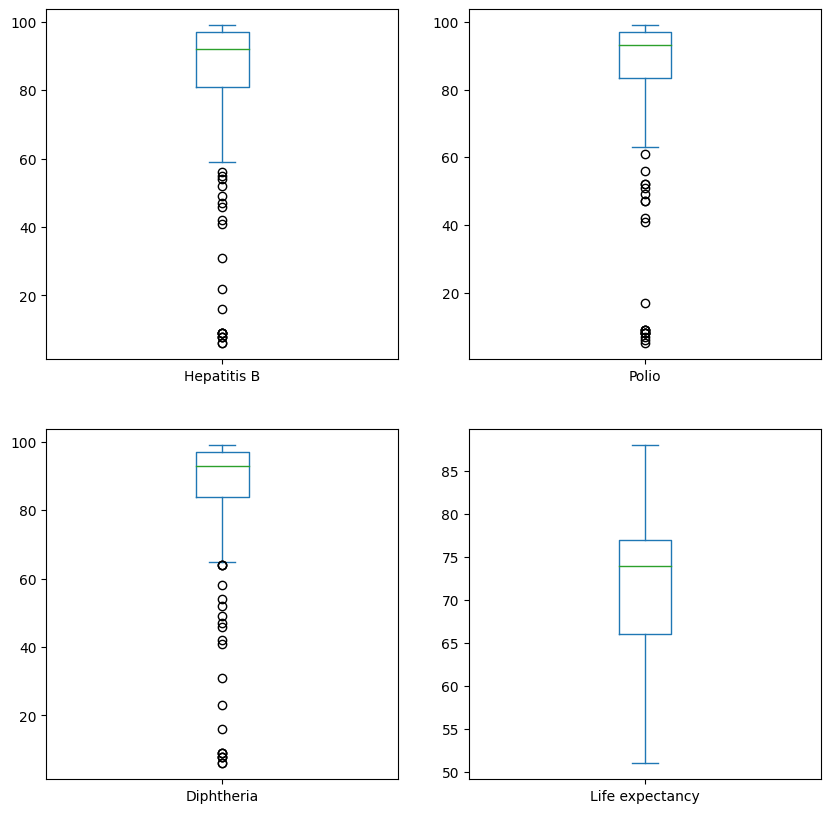

In [32]:
# boxplots of the columns that I will be using, 2015

fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
diseases_2015_df['Hepatitis B'].plot.box(ax=axis[0,0])
diseases_2015_df['Polio'].plot.box(ax=axis[0,1])
diseases_2015_df['Diphtheria'].plot.box(ax=axis[1,0])
diseases_2015_df['Life expectancy'].plot.box(ax=axis[1,1])
plt.show()

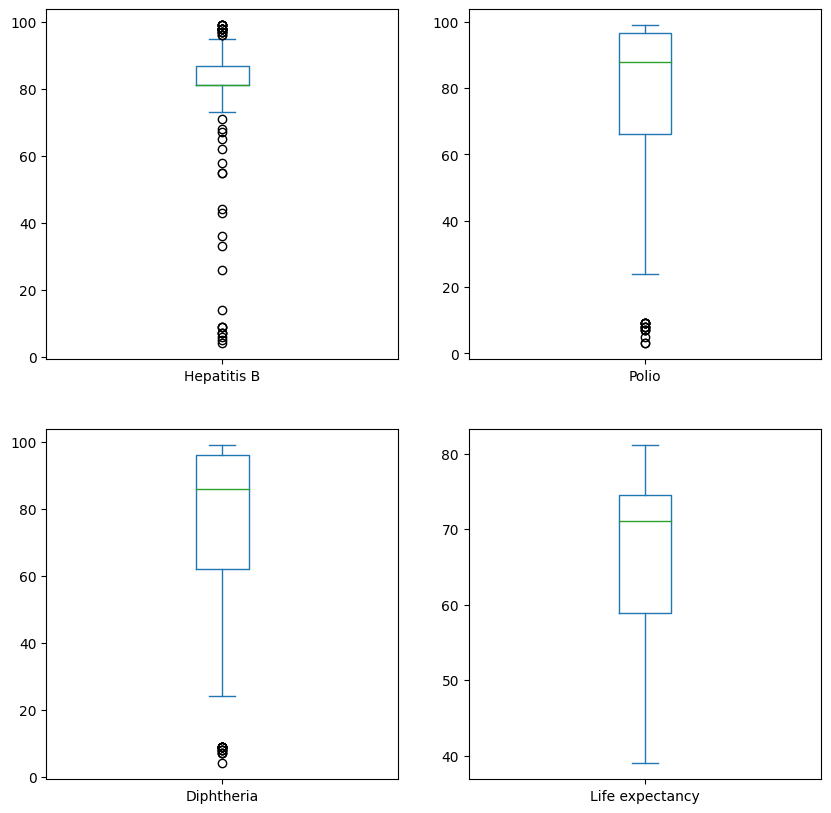

In [34]:
# boxplots of the columns that I will be using, 2000

fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
diseases_2000_df['Hepatitis B'].plot.box(ax=axis[0,0])
diseases_2000_df['Polio'].plot.box(ax=axis[0,1])
diseases_2000_df['Diphtheria'].plot.box(ax=axis[1,0])
diseases_2000_df['Life expectancy'].plot.box(ax=axis[1,1])
plt.show()

In [79]:
# (2) Dealing with outliers

In [80]:
diseases_2015_df['Hepatitis B'] = diseases_2015_df['Hepatitis B'].apply(lambda x: 60 if x <= 61 else x)
diseases_2015_df['Polio'] = diseases_2015_df['Polio'].apply(lambda x: 65 if x <= 64 else x)
diseases_2015_df['Diphtheria'] = diseases_2015_df['Diphtheria'].apply(lambda x: 65 if x <= 64 else x)

C:\Users\DSMSJ\AppData\Local\Temp\ipykernel_17864\1475671458.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diseases_2015_df['Hepatitis B'] = diseases_2015_df['Hepatitis B'].apply(lambda x: 60 if x <= 61 else x)
C:\Users\DSMSJ\AppData\Local\Temp\ipykernel_17864\1475671458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diseases_2015_df['Polio'] = diseases_2015_df['Polio'].apply(lambda x: 65 if x <= 64 else x)
C:\Users\DSMSJ\AppData\Local\Temp\ipykernel_17864\1475671458.py:3: SettingWithCopyWarning:

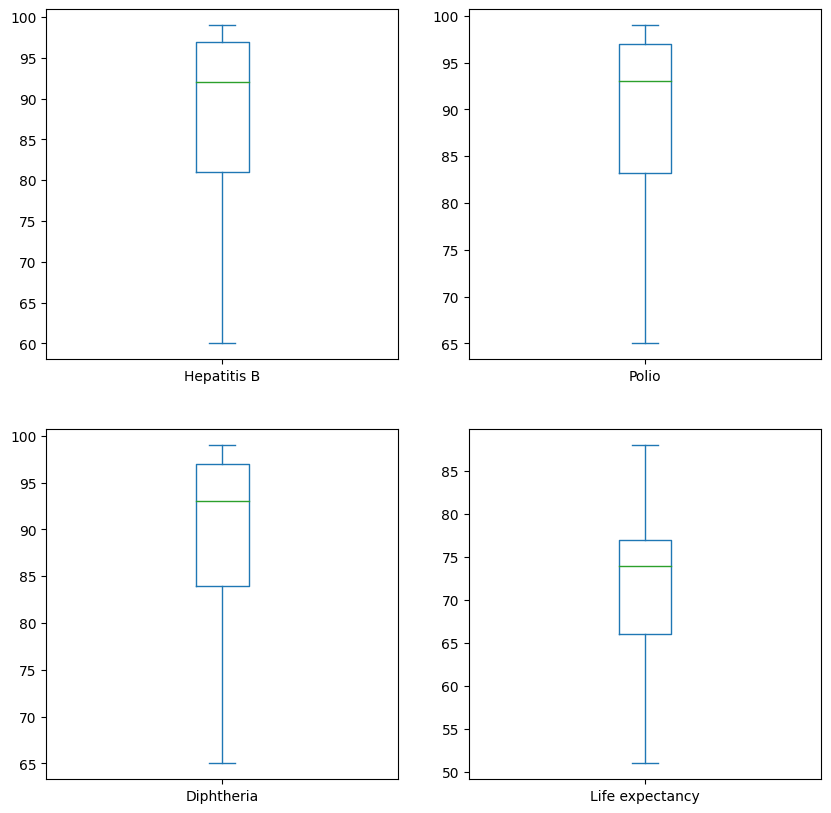

In [81]:
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
diseases_2015_df['Hepatitis B'].plot.box(ax=axis[0,0])
diseases_2015_df['Polio'].plot.box(ax=axis[0,1])
diseases_2015_df['Diphtheria'].plot.box(ax=axis[1,0])
diseases_2015_df['Life expectancy'].plot.box(ax=axis[1,1])
plt.show()

In [41]:
diseases_2000_df['Hepatitis B'] = diseases_2000_df['Hepatitis B'].apply(lambda x: 73 if x <= 74 else x)
diseases_2000_df['Hepatitis B'] = diseases_2000_df['Hepatitis B'].apply(lambda x: 95 if x >= 96 else x)
diseases_2000_df['Polio'] = diseases_2000_df['Polio'].apply(lambda x: 22 if x <= 21 else x)
diseases_2000_df['Diphtheria'] = diseases_2000_df['Diphtheria'].apply(lambda x: 25 if x <= 15 else x)

C:\Users\DSMSJ\AppData\Local\Temp\ipykernel_23708\2549946993.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diseases_2000_df['Hepatitis B'] = diseases_2000_df['Hepatitis B'].apply(lambda x: 73 if x <= 74 else x)
C:\Users\DSMSJ\AppData\Local\Temp\ipykernel_23708\2549946993.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diseases_2000_df['Hepatitis B'] = diseases_2000_df['Hepatitis B'].apply(lambda x: 95 if x >= 96 else x)
C:\Users\DSMSJ\AppData\Local\Temp\ipykernel_23708\2549946993.py:3: SettingWith

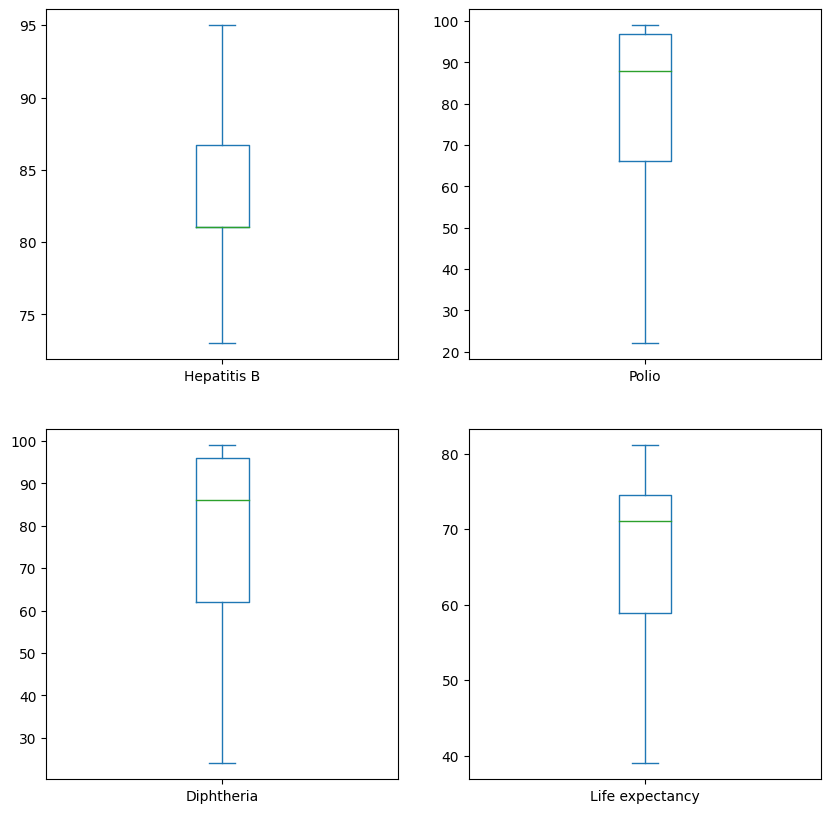

In [42]:
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
diseases_2000_df['Hepatitis B'].plot.box(ax=axis[0,0])
diseases_2000_df['Polio'].plot.box(ax=axis[0,1])
diseases_2000_df['Diphtheria'].plot.box(ax=axis[1,0])
diseases_2000_df['Life expectancy'].plot.box(ax=axis[1,1])
plt.show()

In [43]:
# (3) Explain handeling of outliers

**I chose to use boxplots to show the outliers in the data because boxplots show how the spread of data and it's very easy to see if there are any data points that are way larger or way smaller than the rest of the data. I ended up capping the outliers for each row at a certain value so I could still keep the data from the other columns**

### 3.3 Data quality and consistancy

In [44]:
# (1) Checking for data consistancy and accuracy

In [45]:
diseases_2015_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178 entries, 0 to 2832
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          178 non-null    object 
 1   Year             178 non-null    int64  
 2   Hepatitis B      178 non-null    float64
 3   Polio            178 non-null    float64
 4   Diphtheria       178 non-null    float64
 5   Life expectancy  178 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.7+ KB


In [48]:
diseases_2000_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178 entries, 15 to 2847
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          178 non-null    object 
 1   Year             178 non-null    int64  
 2   Hepatitis B      178 non-null    float64
 3   Polio            178 non-null    float64
 4   Diphtheria       178 non-null    float64
 5   Life expectancy  178 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.7+ KB


In [47]:
diseases_2015_df.sample(10)

,Country,Year,Hepatitis B,Polio,Diphtheria,Life expectancy
1968,Portugal,2015,98.0,98.0,98.0,81.1
608,Croatia,2015,94.0,94.0,94.0,78.0
64,Antigua and Barbuda,2015,99.0,86.0,99.0,76.4
224,Belarus,2015,99.0,99.0,99.0,72.3
1552,Mali,2015,64.0,66.0,64.0,58.2
1520,Malaysia,2015,99.0,99.0,99.0,75.0
1040,Guinea-Bissau,2015,87.0,87.0,87.0,58.9
2192,Seychelles,2015,98.0,97.0,97.0,73.2
2080,Saint Lucia,2015,99.0,99.0,99.0,75.2
2352,Sri Lanka,2015,99.0,99.0,99.0,74.9


In [49]:
diseases_2000_df.sample(10)

,Country,Year,Hepatitis B,Polio,Diphtheria,Life expectancy
2063,Russian Federation,2000,81.08,97.0,96.0,65.0
591,Congo,2000,81.08,31.0,33.0,52.9
223,Barbados,2000,81.08,86.0,93.0,73.3
287,Benin,2000,81.08,78.0,78.0,55.4
1647,Micronesia (Federated States of),2000,87.00,85.0,85.0,67.0
991,Greece,2000,89.00,89.0,89.0,78.2
2239,Singapore,2000,95.00,98.0,98.0,78.3
2751,Uzbekistan,2000,81.08,99.0,99.0,67.1
2015,Republic of Korea,2000,93.00,99.0,97.0,76.0
543,Chile,2000,81.08,91.0,91.0,77.3


In [65]:
# No negative values, 2015

print('Negative in Hepatitis B:', (diseases_2015_df['Hepatitis B'] < 0).any())
print('Negative in Polio:', (diseases_2015_df['Polio'] < 0).any())
print('Negative in Diptheria:', (diseases_2015_df['Diphtheria'] < 0).any())
print('Negative in Life expectancy:', (diseases_2015_df['Life expectancy'] < 0).any())

Negative in Hepatitis B: False
Negative in Polio: False
Negative in Diptheria: False
Negative in Life expectancy: False


In [66]:
# No negative values, 2000

print('Negative in Hepatitis B:', (diseases_2000_df['Hepatitis B'] < 0).any())
print('Negative in Polio:', (diseases_2000_df['Polio'] < 0).any())
print('Negative in Diptheria:', (diseases_2000_df['Diphtheria'] < 0).any())
print('Negative in Life expectancy:', (diseases_2000_df['Life expectancy'] < 0).any())

Negative in Hepatitis B: False
Negative in Polio: False
Negative in Diptheria: False
Negative in Life expectancy: False


In [67]:
# (2) Checking for duplicate records.

In [68]:
diseases_2015_df.duplicated()

0       False
16      False
32      False
48      False
64      False
        ...  
2768    False
2784    False
2800    False
2816    False
2832    False
Length: 178, dtype: bool

In [69]:
diseases_2000_df.duplicated()

15      False
31      False
47      False
63      False
79      False
        ...  
2783    False
2799    False
2815    False
2831    False
2847    False
Length: 178, dtype: bool

In [70]:
# No duplicate data

diseases_2015_df[diseases_2015_df.duplicated()]

,Country,Year,Hepatitis B,Polio,Diphtheria,Life expectancy


In [71]:
diseases_2000_df[diseases_2000_df.duplicated()]

,Country,Year,Hepatitis B,Polio,Diphtheria,Life expectancy


In [72]:
# (3) There was no transformation applied

**No transformations were performed, all data appeared to be consistent. There were no duplicated rows, the diseases and Life expectancy were type float, Country and Status were strings, the year was int. The types make sense and the format was consistent.**

### 3.4 Data preparation for model training

In [73]:
# (1) Converting to a form a model can ingest

In [74]:
X = diseases_df[['Hepatitis B', 'Polio', 'Diphtheria']]
X_2015_hep = diseases_2015_df[['Hepatitis B']]
X_2015_pol = diseases_2015_df[['Polio']]
X_2015_dip = diseases_2015_df[['Diphtheria']]

In [75]:
X_2000_hep = diseases_2000_df[['Hepatitis B']]
X_2000_pol = diseases_2000_df[['Polio']]
X_2000_dip = diseases_2000_df[['Diphtheria']]

In [76]:
Y = diseases_df[['Life expectancy']]
Y_2015 = diseases_2015_df[['Life expectancy']]
Y_2000 = diseases_2000_df[['Life expectancy']]

In [77]:
# (2) Train, validation and test

In [78]:
# training 2015 hepatitis
X_2015_hep_train, X_2015_hep_validation_test, Y_2015_hep_train, Y_2015_hep_validation_test = train_test_split(X_2015_hep,Y_2015, random_state=100, train_size=0.8, shuffle=True)
X_2015_hep_validation, X_2015_hep_test, Y_2015_hep_validation, Y_2015_hep_test = train_test_split(X_2015_hep_validation_test, Y_2015_hep_validation_test, random_state=100, train_size=0.5, shuffle=True)

In [79]:
# training 2015 polio

X_2015_pol_train, X_2015_pol_validation_test, Y_2015_pol_train, Y_2015_pol_validation_test = train_test_split(X_2015_pol,Y_2015, random_state=100, train_size=0.8, shuffle=True)
X_2015_pol_validation, X_2015_pol_test, Y_2015_pol_validation, Y_2015_pol_test = train_test_split(X_2015_pol_validation_test, Y_2015_pol_validation_test, random_state=100, train_size=0.5, shuffle=True)

In [80]:
# training 2015 diphtheria

X_2015_dip_train, X_2015_dip_validation_test, Y_2015_dip_train, Y_2015_dip_validation_test = train_test_split(X_2015_dip,Y_2015, random_state=100, train_size=0.8, shuffle=True)
X_2015_dip_validation, X_2015_dip_test, Y_2015_dip_validation, Y_2015_dip_test = train_test_split(X_2015_dip_validation_test, Y_2015_dip_validation_test, random_state=100, train_size=0.5, shuffle=True)

In [81]:
# training 2000 hepatitis

X_2000_hep_train, X_2000_hep_validation_test, Y_2000_hep_train, Y_2000_hep_validation_test = train_test_split(X_2000_hep,Y_2000, random_state=100, train_size=0.8, shuffle=True)
X_2000_hep_validation, X_2000_hep_test, Y_2000_hep_validation, Y_2000_hep_test = train_test_split(X_2000_hep_validation_test, Y_2000_hep_validation_test, random_state=100, train_size=0.5, shuffle=True)

In [82]:
# training 2000 polio

X_2000_pol_train, X_2000_pol_validation_test, Y_2000_pol_train, Y_2000_pol_validation_test = train_test_split(X_2000_pol,Y_2000, random_state=100, train_size=0.8, shuffle=True)
X_2000_pol_validation, X_2000_pol_test, Y_2000_pol_validation, Y_2000_pol_test = train_test_split(X_2000_pol_validation_test, Y_2000_pol_validation_test, random_state=100, train_size=0.5, shuffle=True)

In [83]:
# training 2000 diphtheria

X_2000_dip_train, X_2000_dip_validation_test, Y_2000_dip_train, Y_2000_dip_validation_test = train_test_split(X_2000_dip,Y_2000, random_state=100, train_size=0.8, shuffle=True)
X_2000_dip_validation, X_2000_dip_test, Y_2000_dip_validation, Y_2000_dip_test = train_test_split(X_2000_dip_validation_test, Y_2000_dip_validation_test, random_state=100, train_size=0.5, shuffle=True)

In [84]:
# (3) Label encoding not needed

In [85]:
# (4) Normalize not needed

In [86]:
# (5) Explain the transformations

**Since the columns that I wanted to look at (disease immunization percentage and life expectancy) were already floats, there wasn't any need to label encode. The three diseases are three separate X values and the Y to the lift expectancy to compare how immunization against the diseases will affect life expectancy.**

## Problem 4: Data Visulaization

**2015 scatter plots**

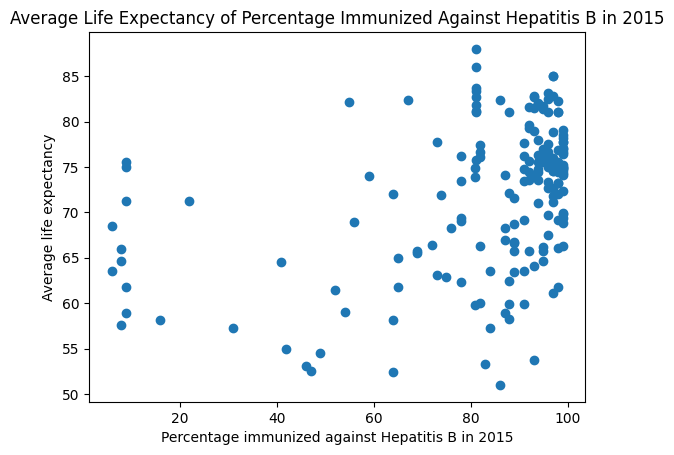

In [87]:
plt.scatter(x=diseases_2015_df['Hepatitis B'].values, y=Y_2015.values)
plt.title('Average Life Expectancy of Percentage Immunized Against Hepatitis B in 2015')
plt.xlabel('Percentage immunized against Hepatitis B in 2015')
plt.ylabel('Average life expectancy')
plt.show()

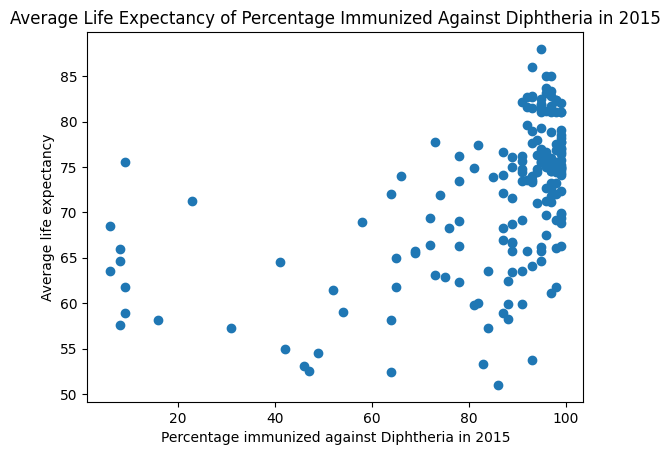

In [88]:
plt.scatter(x=diseases_2015_df['Diphtheria'].values, y=Y_2015.values)
plt.title('Average Life Expectancy of Percentage Immunized Against Diphtheria in 2015')
plt.xlabel('Percentage immunized against Diphtheria in 2015')
plt.ylabel('Average life expectancy')
plt.show()

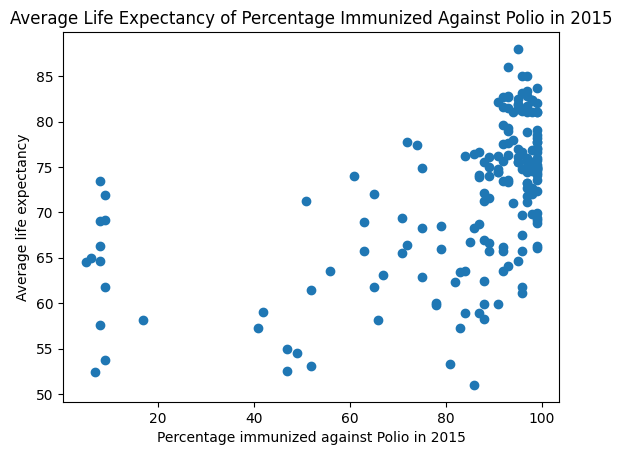

In [89]:
plt.scatter(x=diseases_2015_df['Polio'].values, y=Y_2015.values)
plt.title('Average Life Expectancy of Percentage Immunized Against Polio in 2015')
plt.xlabel('Percentage immunized against Polio in 2015')
plt.ylabel('Average life expectancy')
plt.show()

**2000 scatter plots**

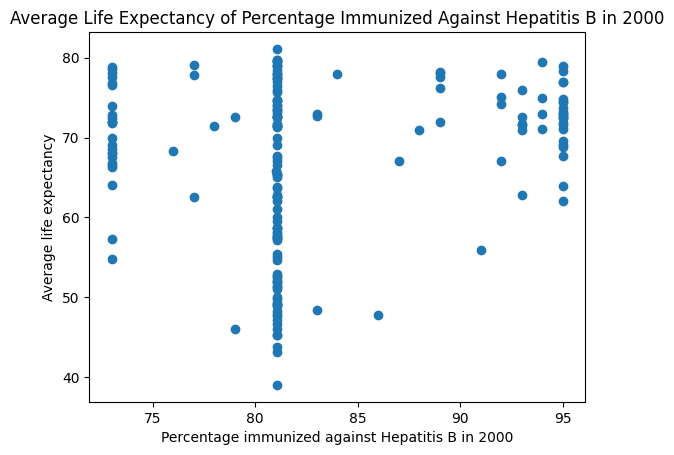

In [90]:
plt.scatter(x=diseases_2000_df['Hepatitis B'].values, y=Y_2000.values)
plt.title('Average Life Expectancy of Percentage Immunized Against Hepatitis B in 2000')
plt.xlabel('Percentage immunized against Hepatitis B in 2000')
plt.ylabel('Average life expectancy')
plt.show()

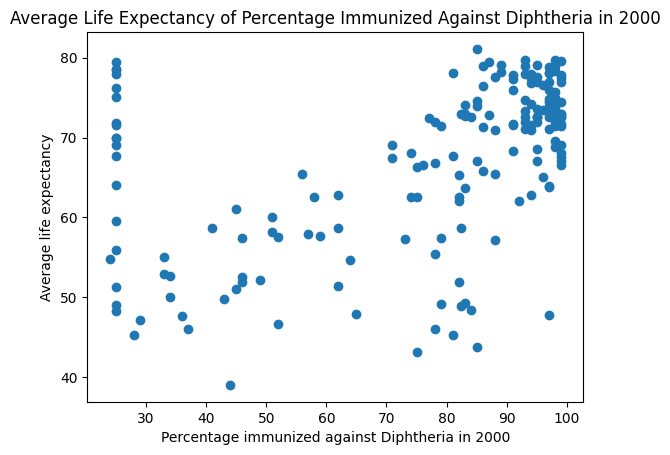

In [91]:
plt.scatter(x=diseases_2000_df['Diphtheria'].values, y=Y_2000.values)
plt.title('Average Life Expectancy of Percentage Immunized Against Diphtheria in 2000')
plt.xlabel('Percentage immunized against Diphtheria in 2000')
plt.ylabel('Average life expectancy')
plt.show()

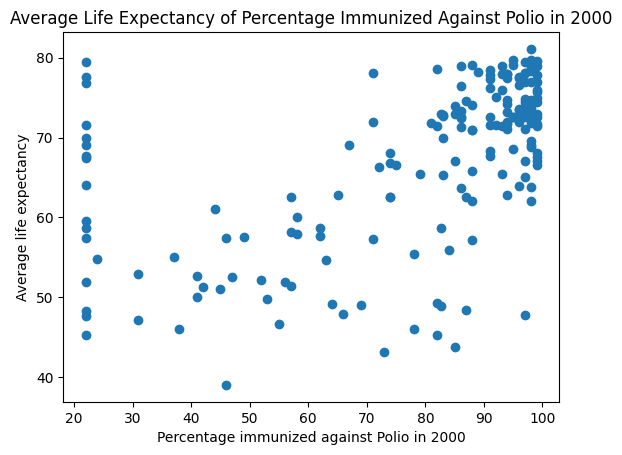

In [92]:
plt.scatter(x=diseases_2000_df['Polio'].values, y=Y_2000.values)
plt.title('Average Life Expectancy of Percentage Immunized Against Polio in 2000')
plt.xlabel('Percentage immunized against Polio in 2000')
plt.ylabel('Average life expectancy')
plt.show()

In [93]:
# Bar chart of average life expectancy each year

In [94]:
avg_life_per_year = []
years = []

year = 2000
for i in range (0, 16):
    years.append(year)
    avg_life = diseases_df[diseases_df['Year'] == year]['Life expectancy'].mean()
    year += 1
    avg_life_per_year.append(avg_life)

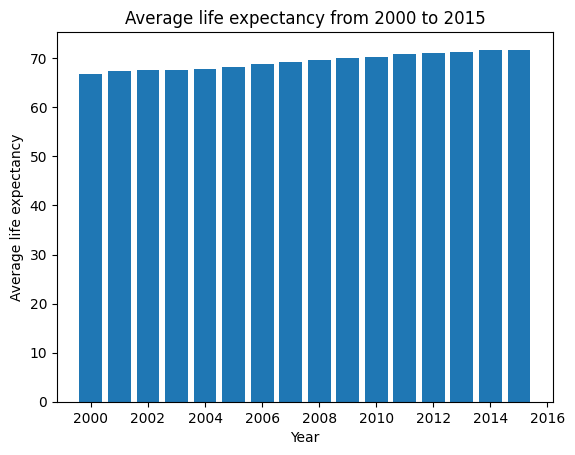

In [95]:
plt.bar(years,avg_life_per_year)
plt.title('Average life expectancy from 2000 to 2015')
plt.xlabel('Year')
plt.ylabel('Average life expectancy')
plt.show()

**I plotted the percentage of the population immunized against each disease and the life expectancy of the percentages for the year 2015 as scatter plots to show how vaccination impacts the life expectancy. I also plotted a bar chart of the average life expectancy from the year 2000-2015 to see if life expectancy goes up or down throughout the years. I chose to look at these two graphs because the dataset contained information from 2000-2015 and the problem I wanted to look at was if higher vaccination percentages meant higher life expectancies. I wanted to see if there was a differnce between the 2015 vaccination percentages and the 2001 vaccination percentages and how their life expectancies compared and that way I could see how vaccination correlated with life expectancy.**

**From the two charts above we can see that there is a slight correlation between the percentage of people immunized and the life expectancy where the greater the immunization percentage the higher the life expectancy. We can also see that life expectancy goes up each year by looking at the bar graph.**

## Problem 5: Model Training

### 5.1 Picking a model

In [96]:
# (1) Pick a machine learning algorithm

The machine learning algorithm that I choose to use is Linear regression

In [97]:
# (2) Paragraph explaining the model

Linear regression is a model that makes predictions for continuous variables. It shows the relationship between independent and dependent variables which makes sense for the problem that I am looking at with my dataset. I want to show that higher immunization percentages mean higher life expectancy and a linear regression model is used to learn and predict the values of certain variables. 

### 5.2 Model training

In [98]:
# (1) Training and reporting on validation dataset

In [99]:
regr = LinearRegression()
regr.fit(X_2015_hep_train, Y_2015_hep_train)
Y_2015_hep_pred = regr.predict(X_2015_hep_validation)

print('Linear regression:',mean_squared_error(Y_2015_hep_validation, Y_2015_hep_pred))

Linear regression: 66.10175861990437


In [100]:
ridge = Ridge()
ridge.fit(X_2015_hep_train, Y_2015_hep_train)
Y_2015_hep_pred = ridge.predict(X_2015_hep_validation)

print('Ridge:',mean_squared_error(Y_2015_hep_validation, Y_2015_hep_pred))

Ridge: 66.10216296213041


In [101]:
lasso = Lasso()
lasso.fit(X_2015_hep_train, Y_2015_hep_train)
Y_2015_hep_pred = lasso.predict(X_2015_hep_validation)

print('Lasso:',mean_squared_error(Y_2015_hep_validation, Y_2015_hep_pred))

Lasso: 66.61256955149523


In [102]:
# Linear regression was the best for Hepatitis in 2015, will use it on the test for all to keep consistancy

In [103]:
# hepatitis, 2015
Y_2015_hep_pred = regr.predict(X_2015_hep_test)
print('Linear regression test:',mean_squared_error(Y_2015_hep_test, Y_2015_hep_pred))

Linear regression test: 95.67637634825718


In [104]:
# line of best fit
b_hep = regr.intercept_
w1_hep = regr.coef_[0]
print(w1_hep,'x +', b_hep, 'b')

[0.11294749] x + [62.58551363] b


In [105]:
# polio, 2015
regr.fit(X_2015_pol_train, Y_2015_pol_train)
Y_2015_pol_pred = regr.predict(X_2015_pol_test)
print('Linear regression test:',mean_squared_error(Y_2015_pol_test, Y_2015_pol_pred))

Linear regression test: 75.64879265133492


In [106]:
# line of best fit
b_pol = regr.intercept_
w1_pol = regr.coef_[0]
print(w1_pol,'x +', b_pol, 'b')

[0.15459615] x + [58.98506168] b


In [107]:
# diphtheria, 2015
regr.fit(X_2015_dip_train, Y_2015_dip_train)
Y_2015_dip_pred = regr.predict(X_2015_dip_test)
print('Linear regression test:',mean_squared_error(Y_2015_dip_test, Y_2015_dip_pred))

Linear regression test: 89.85559372116926


In [108]:
# line of best fit
b_dip = regr.intercept_
w1_dip = regr.coef_[0]
print(w1_dip,'x +', b_dip, 'b')

[0.16310303] x + [58.03354911] b


In [110]:
# hepatitis, 2000
regr.fit(X_2000_hep_train, Y_2000_hep_train)
Y_2000_hep_pred = regr.predict(X_2000_hep_test)
print('Linear regression test:',mean_squared_error(Y_2000_hep_test, Y_2000_hep_pred))

Linear regression test: 105.5264406255551


In [111]:
# line of best fit
b_hep_2000 = regr.intercept_
w1_hep_2000 = regr.coef_[0]
print(w1_hep_2000,'x +', b_hep_2000, 'b')

[0.26363893] x + [45.03024005] b


In [112]:
# polio, 2000
regr.fit(X_2000_pol_train, Y_2000_pol_train)
Y_2000_pol_pred = regr.predict(X_2000_pol_test)
print('Linear regression test:',mean_squared_error(Y_2000_pol_test, Y_2000_pol_pred))

Linear regression test: 76.09073657627347


In [113]:
# line of best fit
b_pol_2000 = regr.intercept_
w1_pol_2000 = regr.coef_[0]
print(w1_pol_2000,'x +', b_pol_2000, 'b')

[0.24034008] x + [48.24128429] b


In [114]:
# diphtheria, 2000
regr.fit(X_2000_dip_train, Y_2000_dip_train)
Y_2000_dip_pred = regr.predict(X_2000_dip_test)
print('Linear regression test:',mean_squared_error(Y_2000_dip_test, Y_2000_dip_pred))

Linear regression test: 73.51825437294801


In [115]:
# line of best fit
b_dip_2000 = regr.intercept_
w1_dip_2000 = regr.coef_[0]
print(w1_dip_2000,'x +', b_dip_2000, 'b')

[0.18466909] x + [53.01109338] b


In [234]:
# (2) Plotting line of best fit from training

### 2015 scatter plots

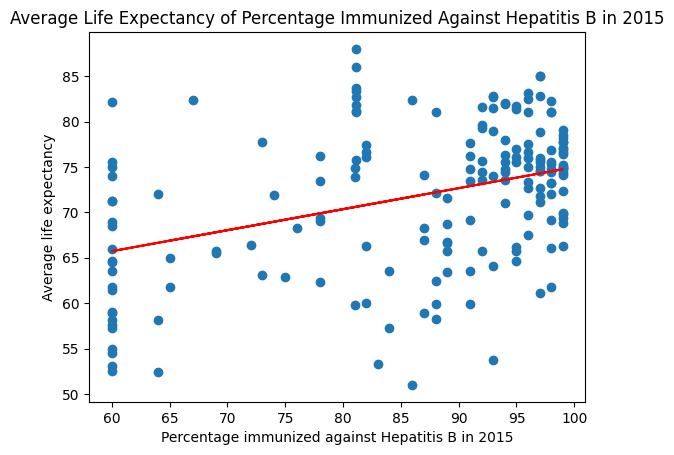

In [242]:
plt.scatter(x=diseases_2015_df['Hepatitis B'].values, y=Y_2015.values)
plt.plot(diseases_2015_df['Hepatitis B'].values, (w1_hep*diseases_2015_df['Hepatitis B'])+b_hep, 'r')
plt.title('Average Life Expectancy of Percentage Immunized Against Hepatitis B in 2015')
plt.xlabel('Percentage immunized against Hepatitis B in 2015')
plt.ylabel('Average life expectancy')
plt.show()

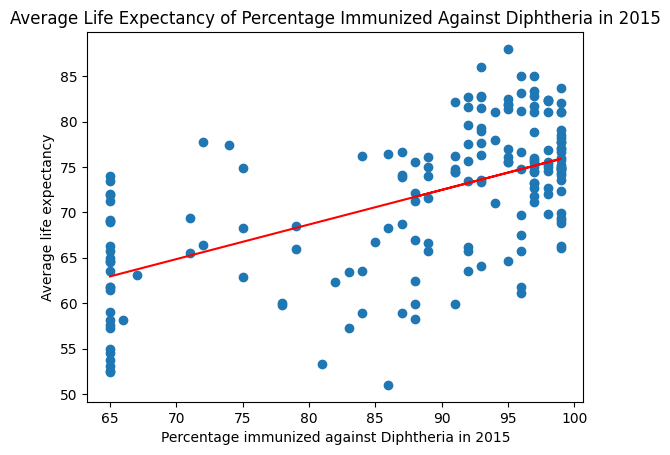

In [243]:
plt.scatter(x=diseases_2015_df['Polio'].values, y=Y_2015.values)
plt.plot(diseases_2015_df['Polio'].values, (w1_pol*diseases_2015_df['Polio'])+b_pol, 'r')
plt.title('Average Life Expectancy of Percentage Immunized Against Diphtheria in 2015')
plt.xlabel('Percentage immunized against Diphtheria in 2015')
plt.ylabel('Average life expectancy')
plt.show()

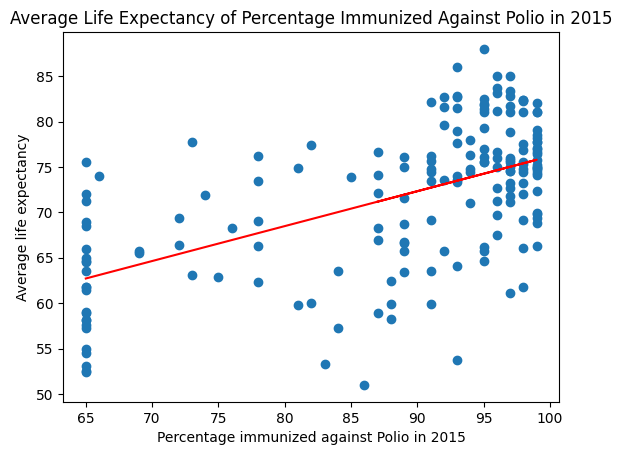

In [244]:
plt.scatter(x=diseases_2015_df['Diphtheria'].values, y=Y_2015.values)
plt.plot(diseases_2015_df['Diphtheria'].values, (w1_dip*diseases_2015_df['Diphtheria'])+b_dip, 'r')
plt.title('Average Life Expectancy of Percentage Immunized Against Polio in 2015')
plt.xlabel('Percentage immunized against Polio in 2015')
plt.ylabel('Average life expectancy')
plt.show()

### 2000 scatter plots

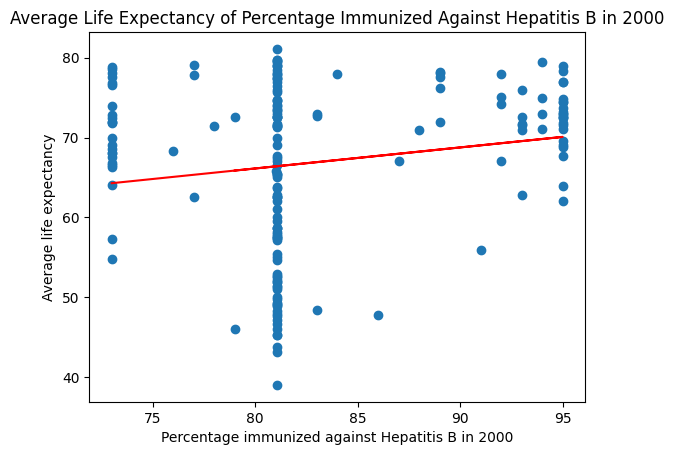

In [117]:
plt.scatter(x=diseases_2000_df['Hepatitis B'].values, y=Y_2000.values)
plt.plot(diseases_2000_df['Hepatitis B'].values, (w1_hep_2000*diseases_2000_df['Hepatitis B'])+b_hep_2000, 'r')
plt.title('Average Life Expectancy of Percentage Immunized Against Hepatitis B in 2000')
plt.xlabel('Percentage immunized against Hepatitis B in 2000')
plt.ylabel('Average life expectancy')
plt.show()

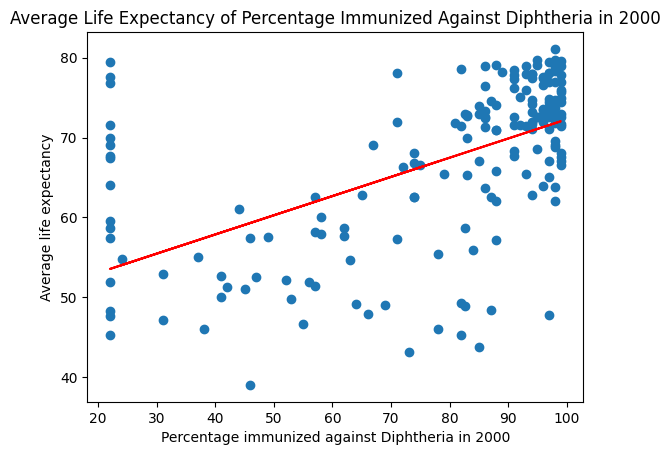

In [118]:
plt.scatter(x=diseases_2000_df['Polio'].values, y=Y_2000.values)
plt.plot(diseases_2000_df['Polio'].values, (w1_pol_2000*diseases_2000_df['Polio'])+b_pol_2000, 'r')
plt.title('Average Life Expectancy of Percentage Immunized Against Diphtheria in 2000')
plt.xlabel('Percentage immunized against Diphtheria in 2000')
plt.ylabel('Average life expectancy')
plt.show()

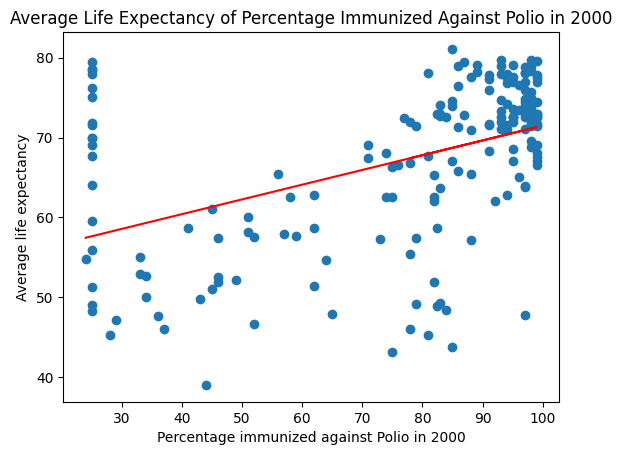

In [119]:
plt.scatter(x=diseases_2000_df['Diphtheria'].values, y=Y_2000.values)
plt.plot(diseases_2000_df['Diphtheria'].values, (w1_dip_2000*diseases_2000_df['Diphtheria'])+b_dip_2000, 'r')
plt.title('Average Life Expectancy of Percentage Immunized Against Polio in 2000')
plt.xlabel('Percentage immunized against Polio in 2000')
plt.ylabel('Average life expectancy')
plt.show()

In [235]:
# (3) Hyperparameters

random state to take random values<br>
training size = 80% <br>
validation size = 10%<br>
test size = 10%<br>

### 5.3 Report results

Graphs with the line of best fit from the test data is shown on the scatter plots above.

From the graphs above we can see that the trend line that the model got with the test data shows a positive slope for all of the diseases. This means that as the percentage of a population that is immunized increases, the life expectancy generally also increases. On the graphs of Hepatitis B vaccination percentages, you can see that vaccination percentage has increased based on how high the x-axis goes. We can also see on the graphs the clusters of data points to get an idea of the number of countries and their vaccination percentages for the years 2000 and 2015. Looking at the y-axis, we can see that the average life expectancy in the year 2000 was lower than in the year 2015 because the graphs of the 2000 data only goes up to 80 years while the life expectancy for the year 2015 goes up to 85 years. 